# Notebook 2: Revenue Estimation and Final Deliverable Construction

This notebook features:

- Loading and organizing the revenue + streams data
- A **quality flagging layer** to catch suspicious low-revenue/high-stream rows (not just missing values).
- Simple baselines rules (**Group Average** and **Naive**) to set a fair performance floor.
- Stronger model-based approaches (**XGBoost, LightGBM, KNN, Linear, Ridge**) plus a transparent reference method (**EPSR**).
- A custom **Lag-Aware Hierarchical Nowcast** method.
- **Distribution-aware stress test** (30 repeats) that mimics real missingness patterns.
- Stress-test results showed **Lag-Aware Hierarchical Nowcast** as the best overall and most stable option, with a small edge over EPSR.
- Using that final rule, we generated production nowcasts for rows with missing/zero revenue and flagged quality issues, and created **90% prediction intervals** for uncertainty.
- Final deliverable dataset is generated with:
    - original vs filled revenue,
    - nowcast status/reason labels for auditability,
    - lower/upper uncertainty bounds,
    - RPS (revenue per 1M streams).
- Reporting and reliability views (by BU, DSP, month, territory) and a DSP trend plot for inspection.
- Output exported in `.csv` and `.xlsx` format.

In [1]:
# Load libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial

In [2]:
# Set working directory to project root
import importlib
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
# Import utilities from migrated utils package
from utils import forecast_utils, model_utils, test_utils

importlib.reload(forecast_utils)
importlib.reload(model_utils)
importlib.reload(test_utils)

from utils.forecast_utils import (
    add_time_columns,
    add_quality_flags,
    add_lag_features,
    evaluate_predictions,
    prepare_eval_frames,
    fit_group_average_lookup,
    apply_group_average_lookup,
    fit_epsr_lookup,
    apply_epsr_lookup,
    run_distribution_backtest,
    build_relative_prediction_intervals,
 )

from utils.model_utils import (
    split_time_holdout,
    fit_predict_xgb_refined,
    fit_predict_lgbm_refined,
    fit_predict_knn_refined,
    fit_predict_linear_refined,
    fit_predict_ridge_refined,
    fit_predict_lag_hier_nowcast,
 )

from utils.test_utils import (
    group_avg_fit_predict,
    naive_fit_predict,
    epsr_fit_predict
 )

## 1. Baselines: Group Average, Naive
As baselines, we consider two rules:

- **Group Average Baseline**: This method calculates the average target value for each group defined by `GROUP_COLS` and uses it as the prediction for missing or zero values.
- **Naive Baseline Rule**: This method uses the most recent non-missing value within each group as the prediction for the current period.

In [4]:
df = pd.read_csv("../data/merged_data.csv", index_col=False)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               2000 non-null   str    
 1   business_unit       2000 non-null   str    
 2   territory_name      2000 non-null   str    
 3   dsp                 2000 non-null   str    
 4   total_streams       2000 non-null   int64  
 5   total_gross_amount  1812 non-null   float64
 6   is_na               2000 non-null   int64  
 7   is_zero             2000 non-null   int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 125.1 KB


In [5]:
# Define global constants
TARGET_COL = 'total_gross_amount'
STREAM_COL = 'total_streams'
GROUP_COLS = ['business_unit', 'territory_name', 'dsp']
CATEGORICAL_COLS = ['business_unit', 'territory_name', 'dsp']
EXCLUDED_EVAL_MONTHS = ['2025-09', '2025-10']  # Excluded because dominated by NaN and zero values

# Fixed-effects quality-flag settings
FE_THRESHOLD_QUANTILE = 0.03
MIN_FLAG_GROUP_ROWS = 24
LOW_REVENUE_THRESHOLD = None

In [6]:
# Quick check: where are missing/zero targets concentrated?
month_missing_profile = (
    df.assign(
        month=pd.to_datetime(df['month']),
        target_flag=((df['is_na'] == 1) | (df['is_zero'] == 1)).astype(int)
    )
    .groupby(df['month'].astype(str))
    .agg(total_rows=('target_flag', 'size'), target_rows=('target_flag', 'sum'))
    .reset_index()
    .rename(columns={'month': 'month_str'})
)

# Calculate the share of missing/zero targets for each month
month_missing_profile['target_share'] = month_missing_profile['target_rows'] / month_missing_profile['total_rows']
month_missing_profile

,month_str,total_rows,target_rows,target_share
0,2025-01-01,200,2,0.01
1,2025-02-01,200,2,0.01
2,2025-03-01,200,2,0.01
3,2025-04-01,200,2,0.01
4,2025-05-01,200,2,0.01
5,2025-06-01,200,2,0.01
6,2025-07-01,200,2,0.01
7,2025-08-01,200,10,0.05
8,2025-09-01,200,82,0.41
9,2025-10-01,200,180,0.90


In [7]:
# Study the distribution of NA, zero, and quality flags
df = add_quality_flags(
    df,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    low_revenue_threshold=LOW_REVENUE_THRESHOLD,
    min_group_rows=MIN_FLAG_GROUP_ROWS,
    fe_threshold_quantile=FE_THRESHOLD_QUANTILE,
 )

# Count flags by business_unit, territory_name, and dsp
flag_counts = df.groupby(['business_unit', 'territory_name', 'dsp'])[[
    'is_na', 'is_zero', 'quality_flag_low_revenue_high_streams'
 ]].sum().reset_index()

# Plot stacked distributions across multiple dimensions
plot_dims = [
    ('business_unit', 'Business Unit'),
    ('territory_name', 'Territory'),
    ('dsp', 'DSP'),
    ('month', 'Month')
]

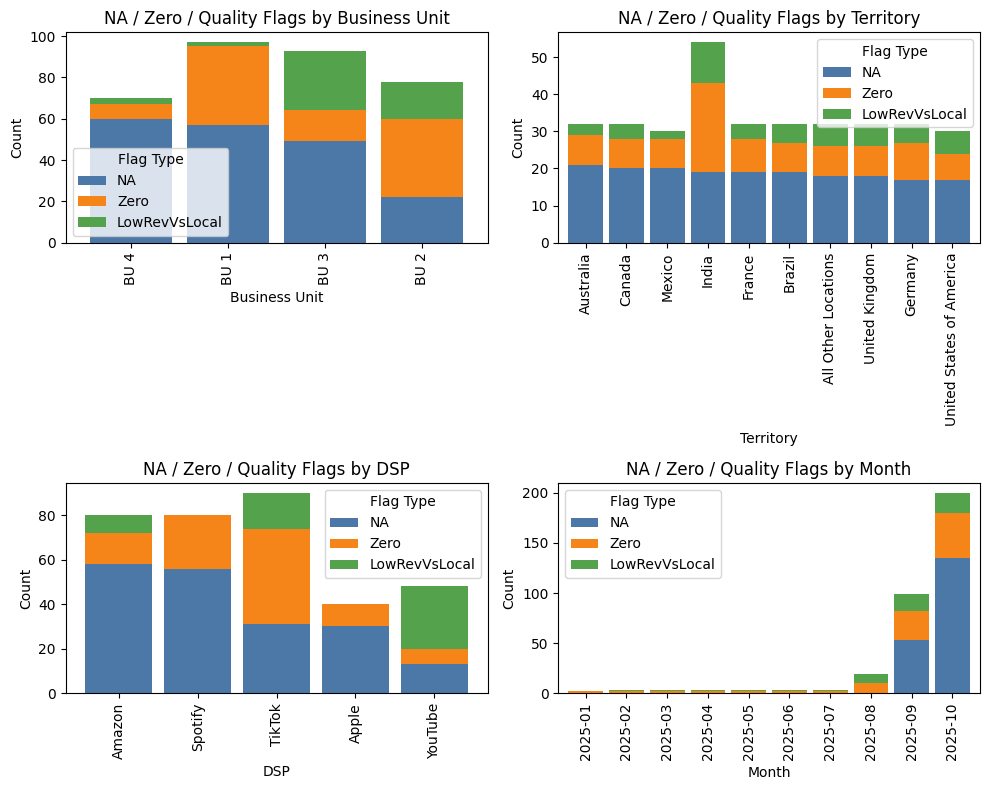

Cohort-aware quality-flag rows: 52


In [8]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plot_dims):
    if col == 'month':
        agg = (
            df.assign(month=pd.to_datetime(df['month']).dt.to_period('M').astype(str))
              .groupby('month')[['is_na', 'is_zero', 'quality_flag_low_revenue_high_streams']]
              .sum()
              .sort_index()
        )
    else:
        agg = (
            flag_counts.groupby(col)[['is_na', 'is_zero', 'quality_flag_low_revenue_high_streams']]
            .sum()
            .sort_values(['is_na', 'is_zero', 'quality_flag_low_revenue_high_streams'], ascending=False)
        )

    agg.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=['#4C78A8', '#F58518', '#54A24B'],
        width=0.85
    )
    ax.set_title(f'NA / Zero / Quality Flags by {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(title='Flag Type', labels=['NA', 'Zero', 'LowRevVsLocal'])

plt.tight_layout()
plt.show()

print('Cohort-aware quality-flag rows:', int(df['quality_flag_low_revenue_high_streams'].sum()))

## Flagging Report

Quality flagging uses a fixed-effects residual rule on `log(revenue/streams)` with additive effects: `territory_name` + `dsp`.
The threshold is learned from the lower tail of known-row residuals.

In [9]:
# Show current quality-flag settings and flagged distribution
flag_config = pd.DataFrame([
    {'parameter': 'method', 'value': 'fixed_effects_log_rps_residual'},
    {'parameter': 'fixed_effects', 'value': 'territory_name + dsp'},
    {'parameter': 'fe_threshold_quantile', 'value': FE_THRESHOLD_QUANTILE},
    {'parameter': 'min_group_rows', 'value': MIN_FLAG_GROUP_ROWS},
    {'parameter': 'low_revenue_threshold', 'value': LOW_REVENUE_THRESHOLD},
])

flagged_rows = df[df['quality_flag_low_revenue_high_streams'] == 1].copy()
flag_by_group = (
    flagged_rows.groupby(['territory_name', 'dsp'])
    .size()
    .reset_index(name='flag_count')
    .sort_values('flag_count', ascending=False)
)

print('Flagging configuration:')
display(flag_config)

Flagging configuration:


,parameter,value
0,method,fixed_effects_log_rps_residual
1,fixed_effects,territory_name + dsp
2,fe_threshold_quantile,0.03
3,min_group_rows,24
4,low_revenue_threshold,None


In [10]:
# Baseline 1: Pure per-group average imputation/nowcasting
work_df, known_all_df, known_eval_df, target_df = prepare_eval_frames(
    data=df,
    stream_col=STREAM_COL,
    excluded_months=EXCLUDED_EVAL_MONTHS
)

group_avg_lookup = fit_group_average_lookup(
    train_known=known_all_df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL
)

group_avg_eval = apply_group_average_lookup(
    score_data=known_eval_df,
    lookup=group_avg_lookup,
    group_cols=GROUP_COLS
)
group_avg_eval = group_avg_eval.rename(columns={'pred': 'group_avg_baseline'})

group_avg_metrics = evaluate_predictions(
    data=group_avg_eval,
    target_col=TARGET_COL,
    pred_col='group_avg_baseline',
    label='Group Average Baseline',
)

In [11]:
# Store baseline prediction on full dataframe
group_avg_all = apply_group_average_lookup(
    score_data=work_df,
    lookup=group_avg_lookup,
    group_cols=GROUP_COLS
)
df = work_df.copy()
df['group_avg_baseline'] = group_avg_all['pred'].values

metric_df = pd.DataFrame([group_avg_metrics])[['Method', 'MAE', 'WMAPE']]

metric_df

,Method,MAE,WMAPE
0,Group Average Baseline,6584.159686,0.111197


In [12]:
# Baseline 2: Naive rule 
naive_df = add_time_columns(df).sort_values(GROUP_COLS + ['month']).copy()
naive_df['naive_baseline'] = naive_df.groupby(GROUP_COLS)[TARGET_COL].shift(1)

known_mask = (naive_df['is_na'] == 0) & (naive_df['is_zero'] == 0) & (naive_df[STREAM_COL] > 0)
included_mask = ~naive_df['month_str'].isin(EXCLUDED_EVAL_MONTHS)

naive_eval = naive_df.loc[known_mask & included_mask & naive_df['naive_baseline'].notna()].copy()
naive_metrics = evaluate_predictions(
    data=naive_eval,
    target_col=TARGET_COL,
    pred_col='naive_baseline',
    label='Naive Baseline',
)

metric_df = pd.concat([metric_df, pd.DataFrame([naive_metrics])], ignore_index=True)
metric_df.sort_values('WMAPE')

,Method,MAE,WMAPE
1,Naive Baseline,5571.952830,0.092685
0,Group Average Baseline,6584.159686,0.111197


## 2. Model-Based Methods (XGBoost, LightGBM, KNN, Linear, Ridge)

In [13]:
# Build lag features once, then create train/eval pools for all model methods
lag_df = add_lag_features(
    data=df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    lag=1
)
lag_df = add_quality_flags(
    lag_df,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    low_revenue_threshold=LOW_REVENUE_THRESHOLD,
    min_group_rows=MIN_FLAG_GROUP_ROWS,
    fe_threshold_quantile=FE_THRESHOLD_QUANTILE,
 )

included_mask = ~lag_df['month_str'].isin(EXCLUDED_EVAL_MONTHS)
known_mask = (lag_df['is_na'] == 0) & (lag_df['is_zero'] == 0) & (lag_df[STREAM_COL] > 0)
target_mask = (lag_df['is_na'] == 1) | (lag_df['is_zero'] == 1)
quality_flag_mask = lag_df['quality_flag_low_revenue_high_streams'] == 1

model_known_eval = lag_df.loc[known_mask & included_mask].copy()
model_target_rows = lag_df.loc[target_mask | quality_flag_mask].copy()

In [14]:
# Keep model registry concise and utility-driven
model_registry = [
    ('XGBoost', partial(fit_predict_xgb_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('LightGBM', partial(fit_predict_lgbm_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('KNN', partial(fit_predict_knn_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('LinearRegression', partial(
        fit_predict_linear_refined,
        categorical_cols=CATEGORICAL_COLS,
        target_col=TARGET_COL,
        stream_col=STREAM_COL,
    )),
    ('Ridge(alpha=10)', partial(
        fit_predict_ridge_refined,
        categorical_cols=CATEGORICAL_COLS,
        target_col=TARGET_COL,
        stream_col=STREAM_COL,
        alpha=10.0,
    )),
]

In [15]:
# Compute the metrics
model_rows = []
for model_name, fit_predict_fn in model_registry:
    train_df, val_df = split_time_holdout(model_known_eval)
    val_df = val_df.copy()
    val_df['model_pred'] = fit_predict_fn(train_df, val_df)

    model_metrics = evaluate_predictions(
        data=val_df,
        target_col=TARGET_COL,
        pred_col='model_pred',
        label=model_name,
    )
    model_rows.append(model_metrics)

In [16]:
# Write each model prediction back to the main dataframe
pred_col_map = {
    'XGBoost': 'xgb_pred',
    'LightGBM': 'lgbm_pred',
    'KNN': 'knn_pred',
    'LinearRegression': 'linear_pred',
    'Ridge(alpha=10)': 'ridge_pred',
}

for model_name, fit_predict_fn in model_registry:
    pred_col = pred_col_map[model_name]
    scored_target = model_target_rows.copy()
    scored_target[pred_col] = fit_predict_fn(model_known_eval, scored_target)
    df[pred_col] = np.nan
    df.loc[scored_target.index, pred_col] = scored_target[pred_col].values

model_method_names = [name for name, _ in model_registry]
metric_df = metric_df[~metric_df['Method'].isin(model_method_names)].copy()
metric_df = pd.concat([metric_df, pd.DataFrame(model_rows)], ignore_index=True)
metric_df = metric_df.sort_values('WMAPE').reset_index(drop=True)

metric_df

,Method,MAE,WMAPE
0,Naive Baseline,5571.952830,0.092685
1,Group Average Baseline,6584.159686,0.111197
2,XGBoost,10135.314310,0.157061
3,Ridge(alpha=10),10774.881945,0.166972
4,LinearRegression,11561.685487,0.179165
5,LightGBM,12255.826339,0.189921
6,KNN,16248.801155,0.251798


## 3. EPSR Reference
EPSR is kept as a simple, transparent reference method.
It helps us judge whether more complex models are actually adding value.

In [17]:
# EPSR reference method
epsr_lookup = fit_epsr_lookup(
    train_known=known_all_df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL
)

# Apply EPSR lookup to evaluation set
epsr_eval = apply_epsr_lookup(
    score_data=known_eval_df,
    lookup=epsr_lookup,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL
)
epsr_eval = epsr_eval.rename(columns={'pred': 'epsr_baseline'})

# Evaluate EPSR predictions in the same cell to avoid run-order issues
epsr_metrics = evaluate_predictions(
    data=epsr_eval,
    target_col=TARGET_COL,
    pred_col='epsr_baseline',
    label='EPSR',
)

In [18]:
# Store EPSR predictions on the full dataframe for fair comparison
epsr_all = apply_epsr_lookup(
    score_data=df,
    lookup=epsr_lookup,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL
)
df['epsr_baseline'] = epsr_all['pred'].values

# Keep metric table idempotent when cells are re-run
metric_df = metric_df[metric_df['Method'] != 'EPSR'].copy()
metric_df = pd.concat([metric_df, pd.DataFrame([epsr_metrics])], ignore_index=True)
metric_df.sort_values('WMAPE')

,Method,MAE,WMAPE
7,EPSR,4880.511846,0.082425
0,Naive Baseline,5571.952830,0.092685
1,Group Average Baseline,6584.159686,0.111197
2,XGBoost,10135.314310,0.157061
3,Ridge(alpha=10),10774.881945,0.166972
4,LinearRegression,11561.685487,0.179165
5,LightGBM,12255.826339,0.189921
6,KNN,16248.801155,0.251798


## 4. Lag-Aware Hierarchical Nowcast


In [19]:
# Evaluate lag-aware nowcast separately and write predictions back
train_df, val_df = split_time_holdout(model_known_eval)
val_df = val_df.copy()
val_df['lag_hier_nowcast_pred'] = fit_predict_lag_hier_nowcast(
    train_data=train_df,
    score_data=val_df,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL,
)

lag_hier_metrics = evaluate_predictions(
    data=val_df,
    target_col=TARGET_COL,
    pred_col='lag_hier_nowcast_pred',
    label='Lag-Aware Hierarchical Nowcast',
)

scored_target = model_target_rows.copy()
scored_target['lag_hier_nowcast_pred'] = fit_predict_lag_hier_nowcast(
    train_data=model_known_eval,
    score_data=scored_target,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL,
)
df['lag_hier_nowcast_pred'] = np.nan
df.loc[scored_target.index, 'lag_hier_nowcast_pred'] = scored_target['lag_hier_nowcast_pred'].values

metric_df = metric_df[metric_df['Method'] != 'Lag-Aware Hierarchical Nowcast'].copy()
metric_df = pd.concat([metric_df, pd.DataFrame([lag_hier_metrics])], ignore_index=True)
metric_df = metric_df.sort_values('WMAPE').reset_index(drop=True)
metric_df

,Method,MAE,WMAPE
0,EPSR,4880.511846,0.082425
1,Lag-Aware Hierarchical Nowcast,5462.909957,0.084655
2,Naive Baseline,5571.952830,0.092685
3,Group Average Baseline,6584.159686,0.111197
4,XGBoost,10135.314310,0.157061
5,Ridge(alpha=10),10774.881945,0.166972
6,LinearRegression,11561.685487,0.179165
7,LightGBM,12255.826339,0.189921
8,KNN,16248.801155,0.251798


## 5. Distribution-Aware Stress Test

- This test simulates production-like missingness by matching the month pattern of real missing/zero rows.
- We repeat the process 30 times so the decision is based on stability, not one lucky split.

In [20]:
# Distribution-aware stress test across baselines and main strategies
stress_source = add_lag_features(
    data=df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    lag=1
)

stress_work, stress_known_all, stress_known_eval, stress_target = prepare_eval_frames(
    data=stress_source,
    stream_col=STREAM_COL,
    excluded_months=EXCLUDED_EVAL_MONTHS
)

stress_target_eval = stress_target[~stress_target['month_str'].isin(EXCLUDED_EVAL_MONTHS)].copy()

In [21]:
# Stress-test registry with simple and consistent model names
stress_registry = [
    ('Group Average', partial(
        group_avg_fit_predict,
        group_cols=GROUP_COLS,
        target_col=TARGET_COL,
    )),
    ('Naive', partial(
        naive_fit_predict,
        group_cols=GROUP_COLS,
        target_col=TARGET_COL,
    )),
    ('EPSR', partial(
        epsr_fit_predict,
        group_cols=GROUP_COLS,
        target_col=TARGET_COL,
        stream_col=STREAM_COL,
    )),
    ('Lag-Aware Hierarchical Nowcast', partial(
        fit_predict_lag_hier_nowcast,
        group_cols=GROUP_COLS,
        stream_col=STREAM_COL,
        target_col=TARGET_COL,
    )),
    ('XGBoost', partial(fit_predict_xgb_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('LightGBM', partial(fit_predict_lgbm_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('KNN', partial(fit_predict_knn_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('LinearRegression', partial(
        fit_predict_linear_refined,
        categorical_cols=CATEGORICAL_COLS,
        target_col=TARGET_COL,
        stream_col=STREAM_COL,
    )),
    ('Ridge(alpha=10)', partial(
        fit_predict_ridge_refined,
        categorical_cols=CATEGORICAL_COLS,
        target_col=TARGET_COL,
        stream_col=STREAM_COL,
        alpha=10.0,
    )),
]

In [22]:
# Run distribution-aware backtest for each method and aggregate results
overall_parts = []
for model_name, fit_predict_fn in stress_registry:
    overall_df, _ = run_distribution_backtest(
        known_pool=stress_known_eval,
        target_pool=stress_target_eval,
        fit_predict_fn=fit_predict_fn,
        target_col=TARGET_COL,
        n_repeats=30,
        random_state=42,
        model_name=model_name,
    )
    overall_parts.append(overall_df)

In [23]:
# Create final summary table of test results
stress_overall = pd.concat(overall_parts, ignore_index=True)
stress_summary = (
    stress_overall.groupby('Model')['WMAPE']
    .agg(mean='mean', std='std', 
         p10=lambda s: s.quantile(0.10), 
         p50='median', 
         p90=lambda s: s.quantile(0.90))
    .reset_index()
    .sort_values('mean')
)

stress_summary

,Model,mean,std,p10,p50,p90
3,Lag-Aware Hierarchical Nowcast,0.100283,0.051641,0.050102,0.094618,0.145108
0,EPSR,0.101979,0.052042,0.050612,0.096408,0.146416
1,Group Average,0.129900,0.048650,0.078474,0.129154,0.185543
4,LightGBM,0.166645,0.124224,0.069138,0.131530,0.314059
8,XGBoost,0.176132,0.119028,0.075238,0.145044,0.288367
6,Naive,0.187067,0.141891,0.076041,0.134553,0.372277
2,KNN,0.273835,0.103885,0.162851,0.262864,0.420568
7,Ridge(alpha=10),0.296854,0.133933,0.155164,0.282942,0.503076
5,LinearRegression,0.306403,0.136913,0.157422,0.304705,0.509710


In [24]:
# Rank models by stress performance and compare each method to EPSR
epsr_mean = stress_summary.loc[stress_summary['Model'] == 'EPSR', 'mean'].iloc[0]

stress_rank_table = stress_summary.copy()
stress_rank_table['delta_vs_epsr'] = stress_rank_table['mean'] - epsr_mean
stress_rank_table = stress_rank_table.sort_values('mean')

stress_rank_table[['Model', 'mean', 'p50', 'p90', 'delta_vs_epsr']]

,Model,mean,p50,p90,delta_vs_epsr
3,Lag-Aware Hierarchical Nowcast,0.100283,0.094618,0.145108,-0.001696
0,EPSR,0.101979,0.096408,0.146416,0.000000
1,Group Average,0.129900,0.129154,0.185543,0.027921
4,LightGBM,0.166645,0.131530,0.314059,0.064666
8,XGBoost,0.176132,0.145044,0.288367,0.074153
6,Naive,0.187067,0.134553,0.372277,0.085088
2,KNN,0.273835,0.262864,0.420568,0.171856
7,Ridge(alpha=10),0.296854,0.282942,0.503076,0.194875
5,LinearRegression,0.306403,0.304705,0.509710,0.204424


## 6. Final Rule Selection

We select the final nowcasting rule using stress-test performance and stability.
- Selected final rule: **Lag-Aware Hierarchical Nowcast**
- Reference method: **EPSR**

In [25]:
# Select the final production rule based on stress-test ranking
final_rule_col = 'lag_hier_nowcast_pred'
final_rule_name = 'Lag-Aware Hierarchical Nowcast'

# Side-by-side view: selected final rule vs EPSR reference
final_rule_summary = stress_rank_table[
    stress_rank_table['Model'].isin([final_rule_name, 'EPSR'])
][['Model', 'mean', 'p50', 'p90', 'delta_vs_epsr']].sort_values('mean')

final_rule_summary

,Model,mean,p50,p90,delta_vs_epsr
3,Lag-Aware Hierarchical Nowcast,0.100283,0.094618,0.145108,-0.001696
0,EPSR,0.101979,0.096408,0.146416,0.000000


## 7. Final Deliverable Dataset

In [26]:
# Build final deliverable with quality-flag correction nowcasting
final_imputed_df = add_quality_flags(
    df,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    low_revenue_threshold=LOW_REVENUE_THRESHOLD,
    min_group_rows=MIN_FLAG_GROUP_ROWS,
    fe_threshold_quantile=FE_THRESHOLD_QUANTILE,
 )

# 1) Original nowcast target: missing or zero revenue
target_mask = (final_imputed_df['is_na'] == 1) | (final_imputed_df['is_zero'] == 1)

# 2) Strict quality-flag target: single/two-digit revenue + large streams
quality_flag_mask = final_imputed_df['quality_flag_low_revenue_high_streams'] == 1

# Combined rows to nowcast
rows_to_nowcast = target_mask | quality_flag_mask

In [27]:
# Train lag-aware nowcast on cleaner known rows (exclude target and quality-flag rows)
lag_source = add_lag_features(
    data=final_imputed_df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    lag=1
)
lag_source = add_quality_flags(
    lag_source,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    low_revenue_threshold=LOW_REVENUE_THRESHOLD,
    min_group_rows=MIN_FLAG_GROUP_ROWS,
    fe_threshold_quantile=FE_THRESHOLD_QUANTILE,
 )

train_mask_clean = (
    (lag_source['is_na'] == 0)
    & (lag_source['is_zero'] == 0)
    & (lag_source[STREAM_COL] > 0)
    & (lag_source['quality_flag_low_revenue_high_streams'] == 0)
)
train_clean_df = lag_source.loc[train_mask_clean].copy()
score_nowcast_df = lag_source.loc[rows_to_nowcast].copy()

In [28]:
# Generate quality-improved nowcasts
score_nowcast_df['nowcast_pred'] = fit_predict_lag_hier_nowcast(
    train_data=train_clean_df,
    score_data=score_nowcast_df,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL,
)

# Calibrate uncertainty on known clean rows, then create 90% bounds for nowcasts
calibration_df = train_clean_df.copy()
calibration_df['calibration_pred'] = fit_predict_lag_hier_nowcast(
    train_data=train_clean_df,
    score_data=calibration_df.copy(),
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL,
)

score_nowcast_df = build_relative_prediction_intervals(
    calibration_df=calibration_df,
    prediction_df=score_nowcast_df,
    pred_col='nowcast_pred',
    actual_col=TARGET_COL,
    calibration_pred_col='calibration_pred',
    group_cols=['territory_name', 'dsp'],
    alpha=0.10,
    min_group_rows=30,
    lower_col='nowcast_lower_90',
    upper_col='nowcast_upper_90',
)

In [29]:
# Keep one final revenue field
final_imputed_df['filled_revenue'] = final_imputed_df[TARGET_COL]
final_imputed_df.loc[score_nowcast_df.index, 'filled_revenue'] = score_nowcast_df['nowcast_pred'].values

# Add uncertainty bounds for rows that were nowcasted
final_imputed_df['nowcast_lower_90'] = np.nan
final_imputed_df['nowcast_upper_90'] = np.nan
final_imputed_df.loc[score_nowcast_df.index, 'nowcast_lower_90'] = score_nowcast_df['nowcast_lower_90'].values
final_imputed_df.loc[score_nowcast_df.index, 'nowcast_upper_90'] = score_nowcast_df['nowcast_upper_90'].values

In [30]:
# Quality and nowcast labeling
# We label those without the need of imputation N/A
final_imputed_df['value_status'] = np.where(rows_to_nowcast, 'nowcasted', 'actual')
final_imputed_df['nowcast_reason'] = np.select(
    [target_mask, quality_flag_mask],
    ['missing_or_zero_revenue', 'quality_flag_low_revenue_high_streams'],
    default='N/A',
)

In [31]:
# Revenue per million streams
final_imputed_df['rps'] = np.where(
    final_imputed_df[STREAM_COL] > 0,
    final_imputed_df['filled_revenue'] / (final_imputed_df[STREAM_COL] / 1_000_000),
    np.nan,
 )

# Keep essential fields, plus quality/audit flags
deliverable_cols = [
    'month', 'business_unit', 'territory_name', 'dsp',
    STREAM_COL, TARGET_COL, 'filled_revenue',
    'nowcast_lower_90', 'nowcast_upper_90',
    'value_status', 'nowcast_reason', 'rps'
 ]
final_deliverable_df = final_imputed_df[deliverable_cols].copy()

In [32]:
# Print final summary stats including quality-flag nowcasting
print('Final rows:', len(final_deliverable_df))
print('Nowcasted rows:', int((final_deliverable_df['value_status'] == 'nowcasted').sum()))
print('  - Missing/zero nowcasted:', int((final_deliverable_df['nowcast_reason'] == 'missing_or_zero_revenue').sum()))
print('  - Quality-flag nowcasted:', int((final_deliverable_df['nowcast_reason'] == 'quality_flag_low_revenue_high_streams').sum()))
print('Actual rows:', int((final_deliverable_df['value_status'] == 'actual').sum()))

Final rows: 2000
Nowcasted rows: 338
  - Missing/zero nowcasted: 286
  - Quality-flag nowcasted: 52
Actual rows: 1662


In [33]:
# Auditable nowcast summary
summary_df = final_deliverable_df.copy()
summary_df['month'] = pd.to_datetime(summary_df['month'])
summary_df['month_str'] = summary_df['month'].dt.to_period('M').astype(str)
summary_df['is_nowcasted'] = (summary_df['value_status'] == 'nowcasted').astype(int)

# For audit clarity: "reported_revenue" keeps original values (NaN treated as 0 in totals)
summary_df['reported_revenue'] = summary_df[TARGET_COL].fillna(0)

In [34]:

def build_summary(data, group_cols):
    """
    Create summary by cohorts.
    """
    base = (
        data.groupby(group_cols, dropna=False)
        .agg(
            total_rows=('is_nowcasted', 'size'),
            nowcast_rows=('is_nowcasted', 'sum'),
            total_streams=(STREAM_COL, 'sum'),
            reported_revenue=('reported_revenue', 'sum'),
            filled_revenue=('filled_revenue', 'sum'),
        )
        .reset_index()
    )

    # Reason split for auditability
    reason_counts = (
        data.loc[data['is_nowcasted'] == 1]
        .groupby(group_cols + ['nowcast_reason'], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename(columns={
            'missing_or_zero_revenue': 'reason_missing_or_zero',
            'quality_flag_low_revenue_high_streams': 'reason_quality_flag'
        })
    )

    out = base.merge(reason_counts, on=group_cols, how='left').fillna(0)
    out['actual_rows'] = out['total_rows'] - out['nowcast_rows']
    out['nowcast_rate_pct'] = (out['nowcast_rows'] / out['total_rows']) * 100
    out['revenue_uplift'] = out['filled_revenue'] - out['reported_revenue']

    # Keep only direct, decision-friendly columns
    keep_cols = (
        group_cols
        + [
            'total_rows', 'actual_rows', 'nowcast_rows', 'nowcast_rate_pct',
            'reason_missing_or_zero', 'reason_quality_flag',
            'total_streams', 'reported_revenue', 'filled_revenue', 'revenue_uplift'
        ]
    )
    keep_cols = [c for c in keep_cols if c in out.columns]

    out = out[keep_cols].sort_values(
        ['nowcast_rate_pct', 'nowcast_rows', 'total_rows'],
        ascending=[False, False, False]
    )

    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(2)
    return out

In [35]:
# Function calls
nowcast_summary_by_bu = build_summary(summary_df, ['business_unit'])
nowcast_summary_by_dsp = build_summary(summary_df, ['dsp'])
nowcast_summary_by_month = build_summary(summary_df, ['month_str']).sort_values('month_str')
nowcast_summary_by_territory = build_summary(summary_df, ['territory_name'])

In [36]:
print("Summary by business_unit")
display(nowcast_summary_by_bu)

Summary by business_unit


,business_unit,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
0,BU 1,500,403,97,19.4,95,2,217067927867,40935802.0,47022389.80,6086587.80
2,BU 3,500,407,93,18.6,64,29,78404999608,10253541.0,12250749.59,1997208.59
1,BU 2,500,422,78,15.6,60,18,986639281604,28495608.0,34878799.82,6383191.82
3,BU 4,500,430,70,14.0,67,3,289288526892,20677818.0,24766889.24,4089071.24


In [37]:
print("Summary by DSP")
display(nowcast_summary_by_dsp)

Summary by DSP


,dsp,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
3,TikTok,400,310,90,22.5,74,16,1148578554178,3054959.0,3522402.31,467443.31
0,Amazon,400,320,80,20.0,72,8,398620438,2000625.0,2731678.06,731053.06
2,Spotify,400,320,80,20.0,80,0,22054517696,37960221.0,48381519.25,10421298.25
4,YouTube,400,352,48,12.0,20,28,397786051177,43360358.0,48578807.61,5218449.61
1,Apple,400,360,40,10.0,40,0,2582992482,13986606.0,15704421.23,1717815.23


In [38]:
print("Summary by month")
display(nowcast_summary_by_month)

Summary by month


,month_str,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
0,2025-01,200,198,2,1.0,2,0,111354840601,10476600.0,10476600.20,0.20
1,2025-02,200,197,3,1.5,2,1,119265727758,10436222.0,10435781.29,-440.71
2,2025-03,200,197,3,1.5,2,1,139377247496,11651598.0,11652701.83,1103.83
3,2025-04,200,197,3,1.5,2,1,159424263810,11784238.0,11791931.22,7693.22
4,2025-05,200,197,3,1.5,2,1,173660657277,11910850.0,11920510.71,9660.71
5,2025-06,200,197,3,1.5,2,1,166723764099,12023088.0,12033426.90,10338.90
6,2025-07,200,197,3,1.5,2,1,172434201247,12774119.0,12781801.01,7682.01
7,2025-08,200,181,19,9.5,10,9,185918226863,12260907.0,12319126.95,58219.95
8,2025-09,200,101,99,49.5,82,17,172260306806,7039722.0,12627545.67,5587823.67
9,2025-10,200,0,200,100.0,180,20,170981500014,5425.0,12879402.66,12873977.66


In [39]:
print("Territories by nowcast rate")
display(nowcast_summary_by_territory)

Territories by nowcast rate


,territory_name,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
6,India,200,146,54,27.0,43,11,80303751773,570199.0,753452.40,183253.40
0,All Other Locations,200,168,32,16.0,26,6,955179234067,21000499.0,25269322.18,4268823.18
1,Australia,200,168,32,16.0,29,3,12891249071,2239542.0,2745081.41,505539.41
2,Brazil,200,168,32,16.0,27,5,73898514714,1838522.0,2277951.62,439429.62
3,Canada,200,168,32,16.0,28,4,18647955069,3306686.0,4031086.22,724400.22
4,France,200,168,32,16.0,28,4,31916401533,2596120.0,3171906.09,575786.09
5,Germany,200,168,32,16.0,27,5,37350449231,5099170.0,6303120.91,1203950.91
8,United Kingdom,200,168,32,16.0,26,6,42506869571,6639957.0,8028366.66,1388409.66
7,Mexico,200,170,30,15.0,28,2,66181635805,1679348.0,2038657.32,359309.32
9,United States of America,200,170,30,15.0,24,6,252524675137,55392726.0,64299883.64,8907157.64


In [40]:
final_deliverable_df[final_deliverable_df["value_status"] == "nowcasted"].sort_values("month").head(5)

,month,business_unit,territory_name,dsp,total_streams,total_gross_amount,filled_revenue,nowcast_lower_90,nowcast_upper_90,value_status,nowcast_reason,rps
33,2025-01-01,BU 1,India,TikTok,629616,0.0,0.141523,0.102551,0.180494,nowcasted,missing_or_zero_revenue,0.224776
133,2025-01-01,BU 3,India,TikTok,281198,0.0,0.063207,0.045801,0.080612,nowcasted,missing_or_zero_revenue,0.224776
233,2025-02-01,BU 1,India,TikTok,818877,0.0,0.179922,0.130376,0.229469,nowcasted,missing_or_zero_revenue,0.219719
284,2025-02-01,BU 2,India,YouTube,2173210993,7608.0,7167.037119,1031.566351,13302.507887,nowcasted,quality_flag_low_revenue_high_streams,3.297902
333,2025-02-01,BU 3,India,TikTok,332502,0.0,0.073057,0.052939,0.093175,nowcasted,missing_or_zero_revenue,0.219719


In [41]:
# Save final outputs
base_name = final_rule_name.replace(' ', '_').lower()
final_deliverable_df.to_csv(f'../data/Nathan_Zhang_CMG_Revenue_Forecast_Oct2025.csv', index=False)
final_deliverable_df.to_excel(f'../data/Nathan_Zhang_CMG_Revenue_Forecast_Oct2025.xlsx', index=False, engine='openpyxl')

## 8. DSP Trend Reliability Audit

In [42]:
# DSP-month reliability audit
viz_df = final_deliverable_df.copy()
viz_df['month'] = pd.to_datetime(viz_df['month'])

viz_df['row_rev_lower'] = np.where(
    viz_df['value_status'] == 'nowcasted',
    viz_df['nowcast_lower_90'],
    viz_df['filled_revenue']
)
viz_df['row_rev_upper'] = np.where(
    viz_df['value_status'] == 'nowcasted',
    viz_df['nowcast_upper_90'],
    viz_df['filled_revenue']
)

In [43]:
# Calculate monthly totals and RPS by DSP, including uncertainty and nowcast rates
monthly_dsp = (
    viz_df.groupby(['month', 'dsp'])
    .agg(
        total_streams=('total_streams', 'sum'),
        revenue_mid=('filled_revenue', 'sum'),
        revenue_lower=('row_rev_lower', 'sum'),
        revenue_upper=('row_rev_upper', 'sum'),
        nowcast_rows=('value_status', lambda s: (s == 'nowcasted').sum()),
        total_rows=('value_status', 'size'),
    )
    .reset_index()
)

monthly_dsp['rps_mid'] = monthly_dsp['revenue_mid'] / (monthly_dsp['total_streams'] / 1_000_000)
monthly_dsp['rps_lower_90'] = monthly_dsp['revenue_lower'] / (monthly_dsp['total_streams'] / 1_000_000)
monthly_dsp['rps_upper_90'] = monthly_dsp['revenue_upper'] / (monthly_dsp['total_streams'] / 1_000_000)
monthly_dsp['nowcast_rate'] = monthly_dsp['nowcast_rows'] / monthly_dsp['total_rows']
monthly_dsp['uncertainty_width_pct'] = (
    (monthly_dsp['revenue_upper'] - monthly_dsp['revenue_lower'])
    / monthly_dsp['revenue_mid'] * 100
)

# Investigate the structure
monthly_dsp.head()

,month,dsp,total_streams,revenue_mid,revenue_lower,revenue_upper,nowcast_rows,total_rows,rps_mid,rps_lower_90,rps_upper_90,nowcast_rate,uncertainty_width_pct
0,2025-01-01,Amazon,31468721,2.168020e+05,2.168020e+05,2.168020e+05,0,40,6889.444283,6889.444283,6889.444283,0.00,0.000000
1,2025-01-01,Apple,261099748,1.680590e+06,1.680590e+06,1.680590e+06,0,40,6436.582237,6436.582237,6436.582237,0.00,0.000000
2,2025-01-01,Spotify,2005308423,4.183147e+06,4.183147e+06,4.183147e+06,0,40,2086.036717,2086.036717,2086.036717,0.00,0.000000
3,2025-01-01,TikTok,85240854071,4.067742e+05,4.067741e+05,4.067743e+05,2,40,4.772057,4.772056,4.772058,0.05,0.000028
4,2025-01-01,YouTube,23816109638,3.989287e+06,3.989287e+06,3.989287e+06,0,40,167.503722,167.503722,167.503722,0.00,0.000000


In [44]:
# Summarize growth and reliability trends by DSP 
growth_summary = (
    monthly_dsp.sort_values('month')
    .groupby('dsp')
    .apply(lambda g: pd.Series({
        'first_month': g['month'].iloc[0].strftime('%Y-%m'),
        'last_month': g['month'].iloc[-1].strftime('%Y-%m'),
        'rps_growth_pct': (g['rps_mid'].iloc[-1] / g['rps_mid'].iloc[0] - 1) * 100,
        'latest_uncertainty_width_pct': (
            (g['rps_upper_90'].iloc[-1] - g['rps_lower_90'].iloc[-1])
            / g['rps_mid'].iloc[-1] * 100
        ),
    }))
    .reset_index()
    .sort_values('rps_growth_pct', ascending=False)
)

print('DSP growth summary:')
display(growth_summary.round(2))

DSP growth summary:


,dsp,first_month,last_month,rps_growth_pct,latest_uncertainty_width_pct
2,Spotify,2025-01,2025-10,4.65,16.02
0,Amazon,2025-01,2025-10,1.84,29.03
1,Apple,2025-01,2025-10,-6.57,23.67
4,YouTube,2025-01,2025-10,-26.83,66.67
3,TikTok,2025-01,2025-10,-39.44,96.40


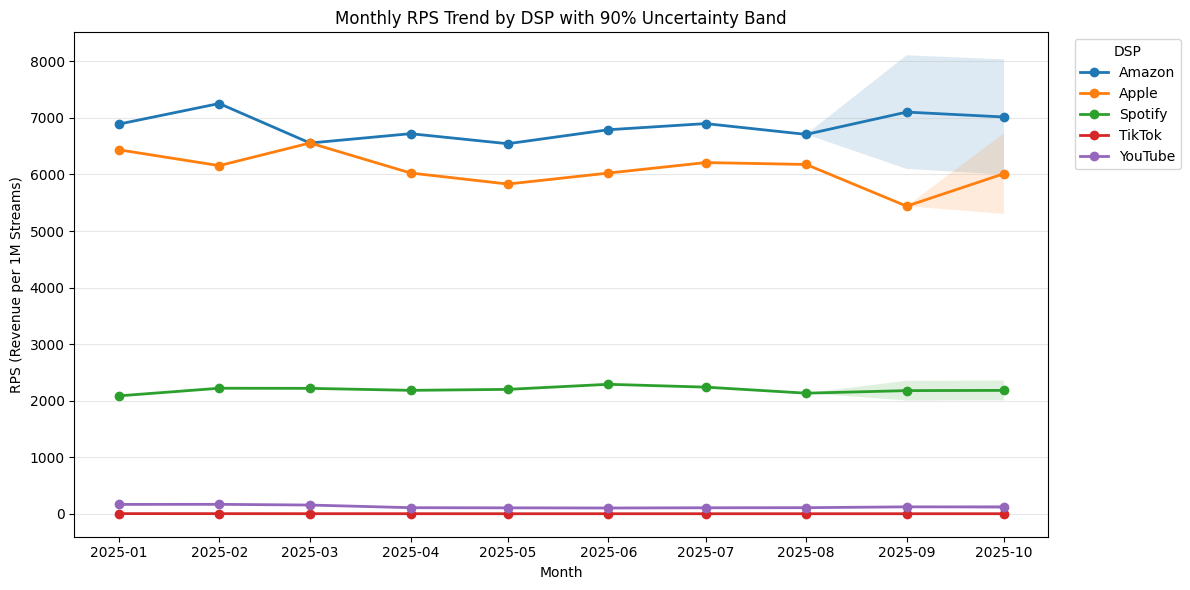

In [45]:
# Visualize monthly RPS trends by DSP with uncertainty bands
plt.figure(figsize=(12, 6))
for dsp_name, group in monthly_dsp.groupby('dsp'):
    group = group.sort_values('month')
    plt.plot(group['month'], group['rps_mid'], marker='o', linewidth=2, label=dsp_name)
    plt.fill_between(group['month'], group['rps_lower_90'], group['rps_upper_90'], alpha=0.15)

plt.title('Monthly RPS Trend by DSP with 90% Uncertainty Band')
plt.xlabel('Month')
plt.ylabel('RPS (Revenue per 1M Streams)')
plt.legend(title='DSP', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()